# 🚢 Titanic Hayatta Kalma Tahmini — LightGBM Classifier

**🇹🇷 Türkçe:**
Bu notebook, klasik **Titanic** veri setinde (891 yolcu) hayatta kalma (`Survived`) tahminini `LGBMClassifier` ile yapıyor. LightGBM, XGBoost ile aynı gradient boosting ailesinden geliyor ama ağaçları **yaprak bazlı (leaf-wise)** büyütüyor; bu genelde daha az ağaçla, daha hızlı bir eğitim anlamına geliyor.

Odak noktası sadece model kurmak değil: `SibSp`/`Parch`'tan `FamilySize` türetmek, bilet paylaşımını hesaba katan `FarePerPerson` özelliği, ve `RandomizedSearchCV` ile hiperparametre aramasının ardından ortaya çıkan **sessiz bir metrik hatası**.

**🇬🇧 English:**
This notebook predicts survival (`Survived`) on the classic **Titanic** dataset (891 passengers) using `LGBMClassifier`. LightGBM belongs to the same gradient boosting family as XGBoost, but grows trees **leaf-wise** rather than level-wise, which usually means faster training with fewer trees.

The focus isn't just building a model: deriving `FamilySize` from `SibSp`/`Parch`, a `FarePerPerson` feature that accounts for shared tickets, and — after a `RandomizedSearchCV` hyperparameter search — a **silent metric bug** that surfaces along the way.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme (`pandas`, `numpy`) ve görselleştirme (`matplotlib`, `seaborn`) için gerekli kütüphaneler yükleniyor.

**🇬🇧 English:**
Loading the libraries needed for data handling (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
Klasik Titanic veri seti okunuyor: 891 yolcu, 12 kolon (`PassengerId`, `Survived`, `Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, `Embarked`).

**🇬🇧 English:**
The classic Titanic dataset is loaded: 891 passengers, 12 columns (`PassengerId`, `Survived`, `Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`, `Ticket`, `Fare`, `Cabin`, `Embarked`).

In [2]:
df = pd.read_csv("../../Data/Titanic-Dataset.csv")

## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
`head()`, tam `df`, `Ticket` kolonunun `value_counts()`'u ve `isnull().sum()` ile veri incelenıyor:

- **`Ticket`** kolonunda aynı numarayı paylaşan gruplar var — en kalabalık biletler (`347082`, `1601`, `CA. 2343`) 7'şer yolcu taşıyor. Bu, birazdan hesaplanacak `FarePerPerson` özelliğinin neden gerekli olduğunu gösteriyor.
- **Eksik değerler:** `Age`'de 177, `Cabin`'de 687 (yolcuların çoğunluğu), `Embarked`'de sadece 2 eksik var.

**🇬🇧 English:**
The data is inspected with `head()`, the full `df`, `value_counts()` on `Ticket`, and `isnull().sum()`:

- **`Ticket`** has groups sharing the same number — the most crowded tickets (`347082`, `1601`, `CA. 2343`) carry 7 passengers each. This is exactly why the `FarePerPerson` feature computed next is needed.
- **Missing values:** 177 in `Age`, 687 in `Cabin` (most passengers), and just 2 in `Embarked`.

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df["Ticket"].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 👪 3. Aile Büyüklüğü ve Kişi Başı Ücret / Family Size & Fare Per Person

**🇹🇷 Türkçe:**
`SibSp + Parch + 1` ile `FamilySize` (yolcunun kendisi dahil aile büyüklüğü) ve `FamilySize == 1` ile `IsAlone` türetiliyor.

Sonrasında `TicketCount` (aynı bileti paylaşan yolcu sayısı, `groupby("Ticket")` ile) hesaplanıp `FarePerPerson = Fare / TicketCount` oluşturuluyor. Bu, doğru tercih: `Fare` kişiye değil **bilete** ait toplam tutar olduğu için (aynı bileti paylaşan 4 kişilik bir grubun her satırında aynı `Fare` yazıyor), bölen olarak `FamilySize` değil `TicketCount` kullanılması gerekiyor — `FamilySize` sadece `SibSp`/`Parch`'tan gelen akraba sayısını sayar, aynı bileti paylaşan akraba olmayan biri ya da farklı bilette seyahat eden bir aile üyesi olduğunda `FamilySize` ile `TicketCount` birbirini tutmaz.

**🇬🇧 English:**
`FamilySize` (`SibSp + Parch + 1`, including the passenger) and `IsAlone` (`FamilySize == 1`) are derived.

Then `TicketCount` (number of passengers sharing the same ticket, via `groupby("Ticket")`) is computed and used to build `FarePerPerson = Fare / TicketCount`. This is the right choice: `Fare` is a total attached to the **ticket**, not the person (everyone sharing a 4-person ticket shows the same `Fare`), so the denominator must be `TicketCount`, not `FamilySize` — `FamilySize` only counts relatives from `SibSp`/`Parch`, and disagrees with `TicketCount` whenever a non-relative shares the ticket or a relative travels on a different one.

In [7]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [8]:
df["TicketCount"] = df.groupby("Ticket")["Ticket"].transform("count")
df["FarePerPerson"] = df["Fare"] / df["TicketCount"]

## 🧹 4. Gereksiz Kolonların Atılması / Dropping Unneeded Columns

**🇹🇷 Türkçe:**
`PassengerId` (salt kimlik numarası), `Name`, `Ticket` (ham metin, bilgisi `TicketCount`'a zaten aktarıldı), `Cabin` (%77 eksik), `SibSp`/`Parch` (`FamilySize`'a toplandı) ve `Fare` (`FarePerPerson`'a dönüştürüldü) atılıyor.

**🇬🇧 English:**
`PassengerId` (a bare identifier), `Name`, `Ticket` (raw text, its information already captured in `TicketCount`), `Cabin` (77% missing), `SibSp`/`Parch` (folded into `FamilySize`), and `Fare` (converted into `FarePerPerson`) are dropped.

In [9]:
df.drop(["PassengerId", "Name","Ticket","Cabin","SibSp","Parch","Fare"], axis=1, inplace=True)

In [10]:
df

,Survived,Pclass,Sex,Age,Embarked,FamilySize,IsAlone,TicketCount,FarePerPerson
0,0,3,male,22.0,S,2,0,1,7.2500
1,1,1,female,38.0,C,2,0,1,71.2833
2,1,3,female,26.0,S,1,1,1,7.9250
3,1,1,female,35.0,S,2,0,2,26.5500
4,0,3,male,35.0,S,1,1,1,8.0500
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,S,1,1,1,13.0000
887,1,1,female,19.0,S,1,1,1,30.0000
888,0,3,female,NaN,S,4,0,2,11.7250
889,1,1,male,26.0,C,1,1,1,30.0000


## 🩹 5. Eksik Değerlerin Doldurulması / Handling Missing Values

**🇹🇷 Türkçe:**
`Embarked`'de sadece 2 eksik değer var; en sık görülen liman olan `"S"` (Southampton, 644/891) ile dolduruluyor.

`Age`'de 177 eksik (≈%20) var. Histogram sağa çarpık olduğu için ortalama yerine **mod** (24.0) ile dolduruluyor — medyan da (28.0) yakın bir değer verirdi, ikisi de savunulabilir bir seçim. Ardından `Sex` ve `Embarked`'in essiz değerleri kontrol ediliyor; bu, encoding'den önce atılacak standart bir sağlık kontrolü.

**🇬🇧 English:**
`Embarked` has only 2 missing values; filled with the most common port, `"S"` (Southampton, 644/891).

`Age` has 177 missing (≈ 20%). Because its histogram is right-skewed, it's filled with the **mode** (24.0) rather than the mean — the median (28.0) would have been close too, either is defensible. The unique values of `Sex` and `Embarked` are then checked, a standard sanity pass before encoding.

In [11]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [12]:
df["Embarked"] = df["Embarked"].fillna("S")

In [13]:
df.isnull().sum()

Survived           0
Pclass             0
Sex                0
Age              177
Embarked           0
FamilySize         0
IsAlone            0
TicketCount        0
FarePerPerson      0
dtype: int64

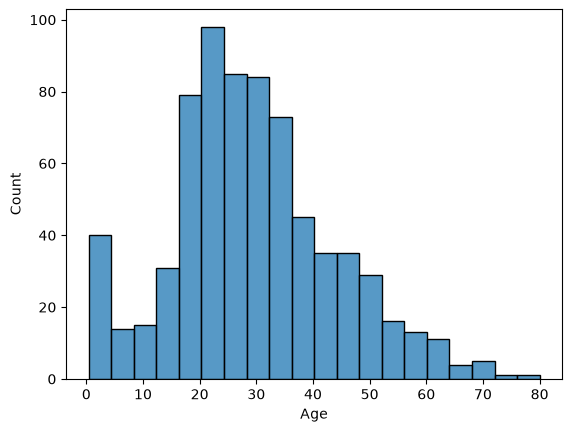

In [14]:
sns.histplot(df["Age"])
plt.show()

In [15]:
df["Age"].median()

np.float64(28.0)

In [16]:
df["Age"].mode()

0    24.0
Name: Age, dtype: float64

In [17]:
df["Age"] = df["Age"].fillna(df["Age"].mode()[0])

In [18]:
cat_cols = ["Sex","Embarked"]
for col in cat_cols:
    print(f"Column: {col}\n{df[col].unique()}\n\n")

Column: Sex
<StringArray>
['male', 'female']
Length: 2, dtype: str


Column: Embarked
<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str




## 🔢 6. Kategorik Kodlama / Categorical Encoding

**🇹🇷 Türkçe:**
`Embarked`, `get_dummies` ile One-Hot Encoding'e tabi tutuluyor; varsayılan olarak `drop_first` uygulanmadığı için 3 kolonun (`Embarked_C`, `Embarked_Q`, `Embarked_S`) hepsi kalıyor — teknik olarak biri gereksiz (üçü de sıfır olamaz), ama LightGBM gibi ağaç tabanlı modeller bu fazlalıktan etkilenmez (bu, doğrusal bir modelde `drop_first=True` gerektirecek bir durum olurdu). `bool` kolonlar `int`'e (`True/False` → `1/0`) çevriliyor, `Sex` doğrudan `map()` ile 0/1'e bağlanıyor, ve artık işi biten `TicketCount` atılıyor.

**🇬🇧 English:**
`Embarked` goes through One-Hot Encoding via `get_dummies`; since `drop_first` isn't applied, all 3 columns (`Embarked_C`, `Embarked_Q`, `Embarked_S`) remain — technically one is redundant (all three can't be zero), but tree-based models like LightGBM are unaffected by that redundancy (a linear model would need `drop_first=True` here). The `bool` columns are cast to `int` (`True/False` → `1/0`), `Sex` is mapped to 0/1 directly, and the now-unused `TicketCount` is dropped.

In [19]:
df = pd.get_dummies(df, columns=["Embarked"])

In [20]:
df

,Survived,Pclass,Sex,Age,FamilySize,IsAlone,TicketCount,FarePerPerson,Embarked_C,Embarked_Q,Embarked_S
0,0,3,male,22.0,2,0,1,7.2500,False,False,True
1,1,1,female,38.0,2,0,1,71.2833,True,False,False
2,1,3,female,26.0,1,1,1,7.9250,False,False,True
3,1,1,female,35.0,2,0,2,26.5500,False,False,True
4,0,3,male,35.0,1,1,1,8.0500,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,1,1,1,13.0000,False,False,True
887,1,1,female,19.0,1,1,1,30.0000,False,False,True
888,0,3,female,24.0,4,0,2,11.7250,False,False,True
889,1,1,male,26.0,1,1,1,30.0000,True,False,False


In [21]:
bool_cols = df.select_dtypes("bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [22]:
df

,Survived,Pclass,Sex,Age,FamilySize,IsAlone,TicketCount,FarePerPerson,Embarked_C,Embarked_Q,Embarked_S
0,0,3,male,22.0,2,0,1,7.2500,0,0,1
1,1,1,female,38.0,2,0,1,71.2833,1,0,0
2,1,3,female,26.0,1,1,1,7.9250,0,0,1
3,1,1,female,35.0,2,0,2,26.5500,0,0,1
4,0,3,male,35.0,1,1,1,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,1,1,1,13.0000,0,0,1
887,1,1,female,19.0,1,1,1,30.0000,0,0,1
888,0,3,female,24.0,4,0,2,11.7250,0,0,1
889,1,1,male,26.0,1,1,1,30.0000,1,0,0


In [23]:
df["Sex"] = df["Sex"].map({"male":0, "female":1})

In [24]:
df

,Survived,Pclass,Sex,Age,FamilySize,IsAlone,TicketCount,FarePerPerson,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,2,0,1,7.2500,0,0,1
1,1,1,1,38.0,2,0,1,71.2833,1,0,0
2,1,3,1,26.0,1,1,1,7.9250,0,0,1
3,1,1,1,35.0,2,0,2,26.5500,0,0,1
4,0,3,0,35.0,1,1,1,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,1,1,1,13.0000,0,0,1
887,1,1,1,19.0,1,1,1,30.0000,0,0,1
888,0,3,1,24.0,4,0,2,11.7250,0,0,1
889,1,1,0,26.0,1,1,1,30.0000,1,0,0


In [25]:
df.drop("TicketCount", axis=1, inplace=True)

## 📊 7. Görselleştirme / Visualization

**🇹🇷 Türkçe:**
Cinsiyete göre hayatta kalma oranı, `Pclass`'a göre hayatta kalma sayımı, yaşa göre dağılım (hayatta kalma kırılımlı) ve korelasyon ısı haritası çiziliyor.

**🇬🇧 English:**
Survival rate by sex, a count plot of survival by `Pclass`, the age distribution split by survival, and a correlation heatmap are plotted.

<Axes: xlabel='Sex', ylabel='Survived'>

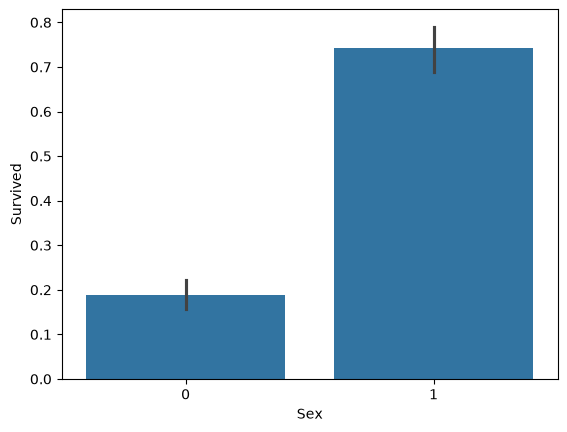

In [26]:
sns.barplot(data=df, x="Sex", y="Survived")

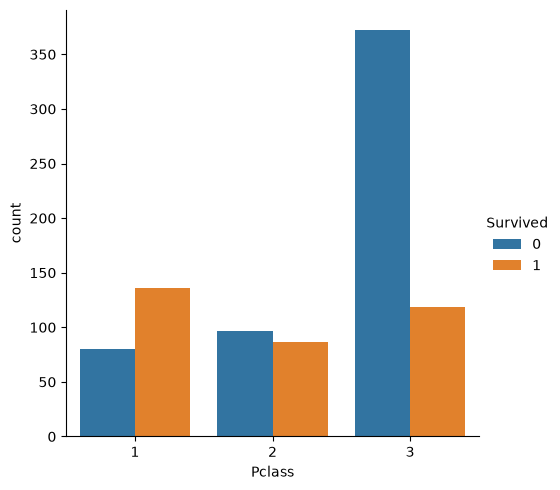

In [27]:
sns.catplot(data=df, x="Pclass", hue="Survived", kind="count")

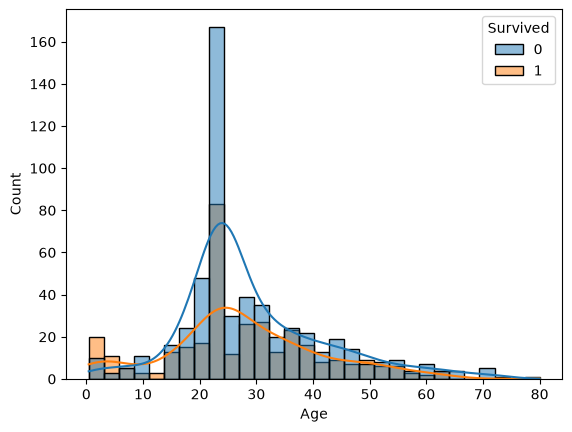

In [28]:
sns.histplot(data=df, x="Age", hue="Survived", kde=True)
plt.show()

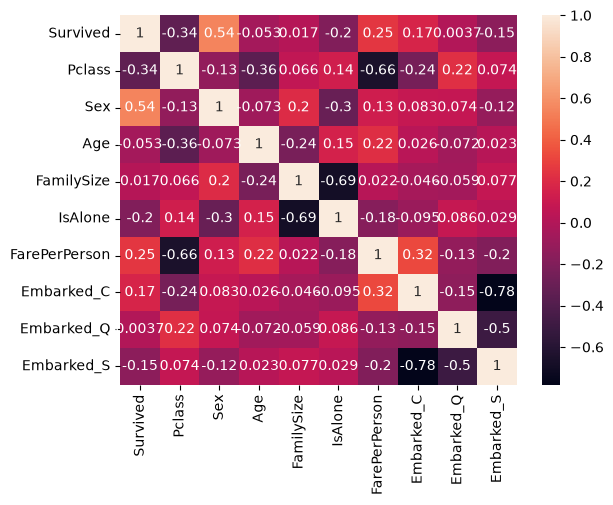

In [29]:
sns.heatmap(df.corr(), annot=True)
plt.show()

## ✂️ 8. Train/Test Ayrımı / Train/Test Split

**🇹🇷 Türkçe:**
Veri %80 eğitim / %20 test olarak bölünüyor. `stratify=y` önemli: `Survived` dengesiz bir hedef (342/891 ≈ %38 hayatta kalan), bu parametre olmadan test setine şans eseri farklı bir oran düşebilirdi.

**🇬🇧 English:**
The data is split 80% train / 20% test. `stratify=y` matters here: `Survived` is an imbalanced target (342/891 ≈ 38% survived), and without this parameter the test set could end up with a different ratio by chance.

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 🚀 9. Temel LightGBM Modeli / Baseline LightGBM Model

**🇹🇷 Türkçe:**
`LGBMClassifier` varsayılan parametrelerle eğitiliyor (`verbosity=-1` sadece LightGBM'in konsol loglarını susturuyor, modeli etkilemiyor). Test setinde **%81 doğruluk**; sınıf 1 (hayatta kalan) için 0.77 precision / 0.72 recall.

`feature_importances_`'a göre `FarePerPerson` (1215) ve `Age` (954) açık ara en belirleyici iki özellik — geri kalan tüm özellikler (`FamilySize` 135, `Sex` 114, `Pclass` 96, ...) bunların çok gerisinde kalıyor.

**🇬🇧 English:**
`LGBMClassifier` is trained with default parameters (`verbosity=-1` only silences LightGBM's console logging, it doesn't affect the model). **81% accuracy** on the test set; 0.77 precision / 0.72 recall for class 1 (survived).

By `feature_importances_`, `FarePerPerson` (1215) and `Age` (954) are by far the two strongest predictors — every other feature (`FamilySize` 135, `Sex` 114, `Pclass` 96, ...) trails far behind.

In [33]:
import lightgbm as lgb

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

In [35]:
clf = lgb.LGBMClassifier(verbosity=-1)
clf.fit(X_train, y_train)

,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [36]:
y_pred = clf.predict(X_test)

In [37]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

[[95 15]
 [19 50]]


In [38]:
feature_names = X_train.columns
pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

FarePerPerson    1215
Age               954
FamilySize        135
Sex               114
Pclass             96
Embarked_S         80
Embarked_C         39
Embarked_Q         27
IsAlone            21
dtype: int32

## 🎯 10. Hiperparametre Optimizasyonu / Hyperparameter Tuning

**🇹🇷 Türkçe:**
7 hiperparametre üzerinde `RandomizedSearchCV` çalıştırılıyor (`n_estimators`, `max_depth`, `learning_rate`, `num_leaves`, `min_child_samples`, `subsample`, `colsample_bytree`). Tam grid 4×4×4×4×3×3×3 = 6.912 kombinasyon eder; `RandomizedSearchCV`'nin varsayılanı `n_iter=10` olduğu için sadece 10 rastgele kombinasyon × 5 kat = 50 fit deneniyor. `GridSearchCV`'nin aksine tüm grid taranmıyor — bulunan "en iyi" kombinasyon, global optimum değil "denenen 10 adayın en iyisi" garantisi taşıyor.

**🇬🇧 English:**
`RandomizedSearchCV` runs over 7 hyperparameters (`n_estimators`, `max_depth`, `learning_rate`, `num_leaves`, `min_child_samples`, `subsample`, `colsample_bytree`). The full grid is 4×4×4×4×3×3×3 = 6,912 combinations; since `RandomizedSearchCV` defaults to `n_iter=10`, only 10 random combinations × 5 folds = 50 fits are actually tried. Unlike `GridSearchCV`, the full grid is never scanned — the "best" combination found only carries the guarantee of being the best among the 10 candidates tried, not the global optimum.

In [39]:
from sklearn.model_selection import RandomizedSearchCV

lgb_model = lgb.LGBMClassifier(verbosity=-1)

param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifier(verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [5, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function w

## ✅ 11. Sonuçlar ve Notlar / Results and Notes

**🇹🇷 Türkçe:**
En iyi kombinasyon: `num_leaves=63, n_estimators=100, min_child_samples=5, max_depth=5, learning_rate=0.05, colsample_bytree=1.0, subsample=0.6`.

**⚠️ Dürüst bir not — sırası karışmış bir metrik çağrısı:** Son hücrede `classification_report(y_pred, y_test)` ve `confusion_matrix(y_pred, y_test)` şeklinde çağrılıyor; doğrusu `classification_report(y_test, y_pred)` olmalı çünkü scikit-learn imzası `(y_true, y_pred)` sırasını bekliyor. Bu, kodu çökertmiyor (iki dizi de aynı boyutta 0/1 değerleri taşıdığı için sessizce çalışıyor) ama **precision ile recall'u birbirine karıştırıyor** ve `support` sütununu yanlış sayıyor — fonksiyon "hangi diziyi gerçek etiket sanıyorsa" support'u ondan hesaplıyor.

Notebook'ta basılan (hatalı sıralı) çıktı ile gerçek (doğru sıralı) çıktı:

| | Notebook'ta basılan (hatalı) | Gerçek (doğru sıra) |
|---|---|---|
| Sınıf 0 precision / recall | 0.92 / 0.81 | **0.81 / 0.92** |
| Sınıf 1 precision / recall | 0.67 / 0.84 | **0.84 / 0.67** |
| Sınıf 1 support | 55 | **69** |
| Accuracy | 0.82 | 0.82 (değişmiyor) |

`accuracy` değişmiyor çünkü toplam doğru tahmin sayısı sıradan etkilenmiyor; ama precision/recall tam olarak yer değiştiriyor (matematiksel olarak confusion matrix'in devriği alınmış oluyor). Gerçek tablo şunu gösteriyor: ayar (tuning) işlemi hayatta kalanları (sınıf 1) yakalama gücünü (recall) **0.72'den 0.67'ye düşürmüş**, buna karşılık o sınıf için kesinliği (precision) 0.77'den 0.84'e çıkarmış — yani model ayar sonrası "hayatta kaldı" demekte daha temkinli ama daha az kapsayıcı hale gelmiş. Sadece accuracy'ye (0.81→0.82) bakan biri bu değişimi tamamen kaçırırdı.

**🇬🇧 English:**
Best combination: `num_leaves=63, n_estimators=100, min_child_samples=5, max_depth=5, learning_rate=0.05, colsample_bytree=1.0, subsample=0.6`.

**⚠️ An honest note — a metric call with swapped arguments:** The final cell calls `classification_report(y_pred, y_test)` and `confusion_matrix(y_pred, y_test)`; the correct call is `classification_report(y_test, y_pred)`, since scikit-learn's signature expects `(y_true, y_pred)`. This doesn't crash anything (both arrays are same-shaped 0/1 values, so it runs silently), but it **swaps precision and recall**, and miscounts the `support` column — the function computes support from whichever array it's told is the true label.

What the notebook printed (wrong order) versus the actual (correct-order) numbers:

| | Printed in notebook (buggy) | Actual (correct order) |
|---|---|---|
| Class 0 precision / recall | 0.92 / 0.81 | **0.81 / 0.92** |
| Class 1 precision / recall | 0.67 / 0.84 | **0.84 / 0.67** |
| Class 1 support | 55 | **69** |
| Accuracy | 0.82 | 0.82 (unchanged) |

`accuracy` is unaffected because the total count of correct predictions doesn't depend on argument order; but precision and recall are exactly swapped (mathematically, the confusion matrix is transposed). The real table shows tuning actually **lowered** recall on survivors (class 1) from 0.72 to 0.67, while raising precision on that class from 0.77 to 0.84 — the model became more conservative but less comprehensive about predicting survival after tuning. Looking only at accuracy (0.81→0.82) would have completely missed this trade-off.

In [40]:
random_search.best_params_

{'subsample': 0.6,
 'num_leaves': 63,
 'n_estimators': 100,
 'min_child_samples': 5,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [41]:
y_pred = random_search.predict(X_test)

In [42]:
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       124
           1       0.67      0.84      0.74        55

    accuracy                           0.82       179
   macro avg       0.79      0.83      0.80       179
weighted avg       0.84      0.82      0.83       179

[[101  23]
 [  9  46]]
